In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Preprocessing

In [35]:
def load_and_preprocess_for_cnn(file_path, sequence_length=60):
    print("Loading and preparing data...")
    data = pd.read_csv(file_path)

    required_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
    if not all(col in data.columns for col in required_cols):
        # Assuming the necessary columns exist
        data = data[required_cols].copy()

    data['Date'] = pd.to_datetime(data['Date'])
    data.dropna(inplace=True)
    data.sort_values('Date', inplace=True)

    feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    scaled_X = scaler_X.fit_transform(data[feature_cols])
    scaled_y = scaler_y.fit_transform(data[['Close']])

    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(scaled_X[i-sequence_length:i])
        y.append(scaled_y[i])

    X, y = np.array(X), np.array(y)

    split_point = int(len(X) * 0.8)

    X_train = X[:split_point]
    y_train = y[:split_point]
    X_test = X[split_point:]
    y_test = y[split_point:]

    print(f"Data ready. X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

    return X_train, X_test, y_train, y_test, scaler_X, scaler_y, data

# Model and Evaluation Functions

In [43]:
def build_cnn_model(input_shape, learning_rate=0.0005, dropout_rate=0.1):
    model = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Dropout(dropout_rate),
        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

# Evaluation Function (Defined here)
def evaluate_and_visualize(model, history, X_test, y_test, scaler_y):
    print("\n--- Model Prediction ---")
    scaled_predictions = model.predict(X_test, verbose=0)

    # Metrics on scaled Prices
    print("\nModel Evaluation (on Scaled Prices 0-1):")
    mse_scaled = mean_squared_error(y_test, scaled_predictions)
    rmse_scaled = np.sqrt(mse_scaled)
    mae_scaled = mean_absolute_error(y_test, scaled_predictions)
    r2_scaled = r2_score(y_test, scaled_predictions)

    print(f"MSE (Scaled)  : {mse_scaled:.8f}")
    print(f"RMSE (Scaled) : {rmse_scaled:.8f}")
    print(f"R² (Scaled)   : {r2_scaled:.4f}")

    # Metrics on ACTUAL (Unscaled) Prices
    y_pred_actual = scaler_y.inverse_transform(scaled_predictions.reshape(-1, 1))
    y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1))

    print("\n--- Additional Context (on Actual Prices) ---")
    mse_actual = mean_squared_error(y_test_actual, y_pred_actual)
    r2_actual = r2_score(y_test_actual, y_pred_actual)

    print(f"MSE (Actual)  : {mse_actual:.4f}")
    print(f"R² (Actual)   : {r2_actual:.4f}")

    # Visualization (Actual vs Predicted)
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_actual, 'b', label='Actual Price')
    plt.plot(y_pred_actual, 'g', label='Predicted Price')
    plt.title('1D CNN Actual vs Predicted Stock Prices (BAJAJ-AUTO) - Tuned')
    plt.xlabel('Time Step')
    plt.ylabel('Close Price')
    plt.legend()
    plt.show()

    # Visualize Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('1D CNN Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()

    return model

# Data Loading and Model Compilation

In [46]:
file_path = '/content/drive/MyDrive/DataSets/BAJAJ-AUTO.csv'

SEQUENCE_LENGTH = 60
EPOCHS = 50
BATCH_SIZE = 32

try:
    # Load and Preprocess Data
    X_train, X_test, y_train, y_test, scaler_X, scaler_y, data = load_and_preprocess_for_cnn(file_path, SEQUENCE_LENGTH)

    # Build Model
    input_shape = (X_train.shape[1], X_train.shape[2]) # (60, 5)

    # Pass custom learning rate and dropout rate
    model = build_cnn_model(input_shape, learning_rate=0.0005, dropout_rate=0.1)

    print("\n--- 1D CNN Model Summary ---")
    model.summary()

    # Define EarlyStopping callback to prevent unnecessary long training if no improvement
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

except FileNotFoundError:
    print(f"ERROR: File not found at the specified path: {file_path}. Please check your file path.")
except Exception as e:
    print(f"An error occurred in Cell 3: {e}")

Loading and preparing data...
Data ready. X_train shape: (1916, 60, 5), X_test shape: (480, 60, 5)

--- 1D CNN Model Summary ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_20 (Conv1D)              │ (None, 58, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_21 (Conv1D)              │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_21 (MaxPooling1D) │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 1664)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       106,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,353 (517.00 KB)

 Trainable params: 132,353 (517.00 KB)

 Non-trainable params: 0 (0.00 B)

# Training, Evaluation, and Visualization


--- Starting Model Training (Epochs: 50) ---
Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0306 - mae: 0.1127 - val_loss: 0.0209 - val_mae: 0.1219
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0023 - mae: 0.0387 - val_loss: 0.0193 - val_mae: 0.1212
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - mae: 0.0337 - val_loss: 0.0127 - val_mae: 0.0968
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0014 - mae: 0.0303 - val_loss: 0.0118 - val_mae: 0.0952
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0014 - mae: 0.0296 - val_loss: 0.0132 - val_mae: 0.1029
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0013 - mae: 0.0280 - val_loss: 0.0090 - val_mae: 0.0814
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0013 - mae: 0.0282 - val_loss: 0.0109 - val_mae: 0.0925
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0010 - mae: 0.0255 - val_loss: 0.0177 - val_mae: 0.1227
Epoch 9/50
60/60 ━

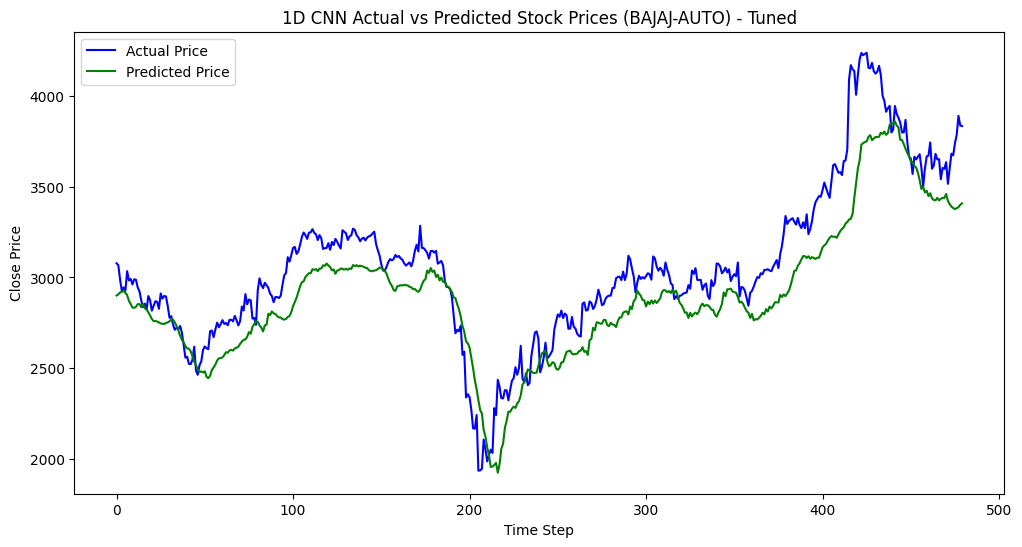

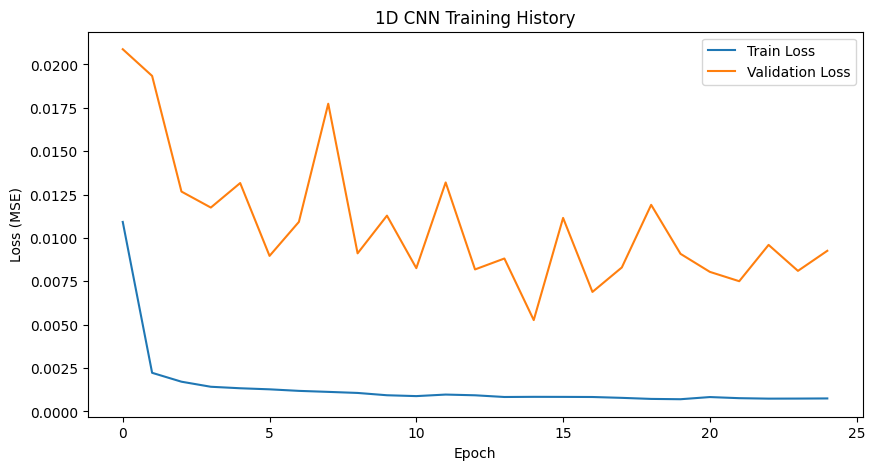


--- Next Day Stock Price Prediction (1D CNN) ---
Predicted Next Day Close Value (1D CNN): 3431.78


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [47]:
# Ensure the model object exists
if 'model' in locals():
    # Train Model
    print(f"\n--- Starting Model Training (Epochs: {EPOCHS}) ---")
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop], # Use Early Stopping here
        verbose=1
    )

    print("\n--- Evaluation and Visualization ---")
    evaluate_and_visualize(model, history, X_test, y_test, scaler_y)

else:
    print("ERROR: Model object not found. Please ensure Cell 3 ran successfully.")



print("\n--- Next Day Stock Price Prediction (1D CNN) ---")
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
full_data_features = data[feature_cols].values

scaled_full_data = scaler_X.transform(full_data_features)

SEQUENCE_LENGTH = 60
last_sequence = scaled_full_data[-SEQUENCE_LENGTH:]

X_input = np.reshape(last_sequence, (1, SEQUENCE_LENGTH, len(feature_cols)))
next_scaled_close = model.predict(X_input, verbose=0)

# Inverse transform the result to get the actual price
next_actual_close = scaler_y.inverse_transform(next_scaled_close.reshape(-1, 1))

print(f"Predicted Next Day Close Value (1D CNN): {next_actual_close[0][0]:.2f}")

